# Retail Radar - Day 2
## Data Cleaning & Exploratory Data Analysis

Bu notebook kapsamında Online Retail veri seti üzerinde veri temizleme,
veri kalitesi analizi ve temel keşifsel veri analizi gerçekleştirilecektir.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.shape

KeyboardInterrupt: 

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df["Revenue"] = df["Quantity"]* df["UnitPrice"]

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate kayıt sayısı: ", duplicate_count)

Duplicate kayıt sayısı:  5268


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(536641, 9)

In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [ ]:
df[df["Description"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0


In [ ]:
df[df["Description"].isnull()]["UnitPrice"].value_counts()

UnitPrice
0.0    1454
Name: count, dtype: int64

In [ ]:
df[df["Description"].isnull()]["Quantity"].describe()

count    1454.000000
mean       -9.359697
std       243.238758
min     -3667.000000
25%       -24.000000
50%        -3.000000
75%         4.000000
max      5568.000000
Name: Quantity, dtype: float64

In [42]:
df[df["Description"].isnull()]["Quantity"].apply(
    lambda x: "negative" if x < 0 else "positive" if x > 0 else "zero"
).value_counts()

Quantity
negative    862
positive    592
Name: count, dtype: int64

In [43]:
missing_desc = df[df["Description"].isnull()].copy()

missing_desc["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    1454
Name: count, dtype: int64

In [ ]:
(df["Quantity"]<0).sum()


np.int64(10587)

In [28]:
returns = df[df["Quantity"]<0].copy()

In [29]:
sales = df[df["Quantity"]>0].copy()

In [31]:
(df["Quantity"] == 0).sum()

np.int64(0)

In [32]:
(df["UnitPrice"] <= 0).sum()

np.int64(2512)

In [33]:
country_quantity = (
    sales.groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

In [34]:
country_quantity.head(10)

Country
United Kingdom    4718329
Netherlands        200937
EIRE               147281
Germany            119156
France             112061
Australia           84199
Sweden              36078
Switzerland         30618
Spain               27944
Japan               26016
Name: Quantity, dtype: int64

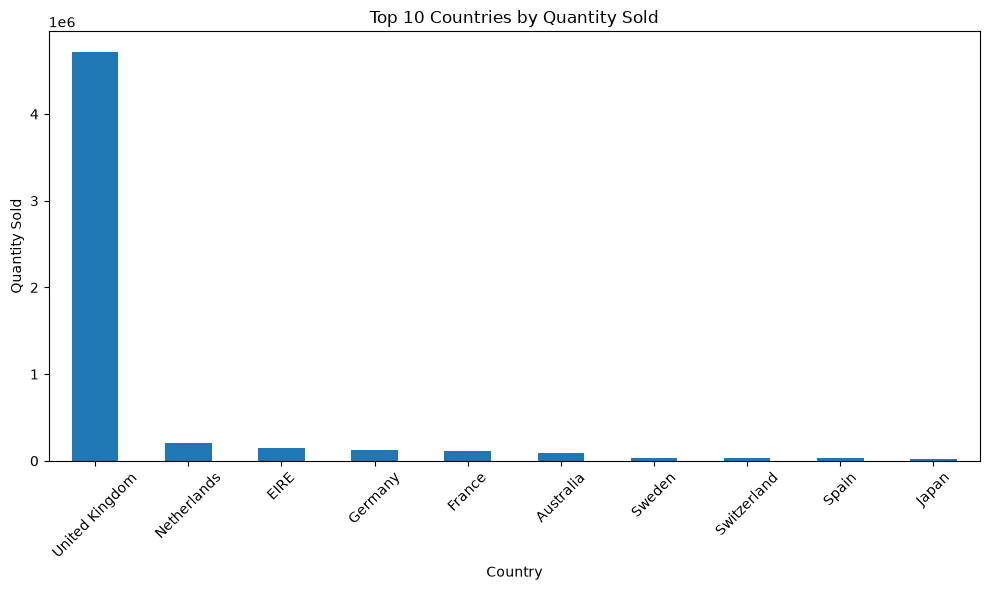

In [35]:
plt.figure(figsize=(10,6))

country_quantity.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()